# Lecture 8 - LaTeX/Overleaf, and Mathematical Complexity

For our course projects, it is very likely that everyone will need to not only put text into their report, but also equations. For traditional word processors (e.g. Word Docs, Apple Pages, Open Office, etc.), this can be cumbersome and time consuming, because for these platforms equations are not needed to be called often. When called, they can also often look a little clunky.

Scientists instead tend to write documents in LaTeX, a a software system used to prepare and format high-quality documents, especially technical ones where equations are used often. There is a bit of a learning curve to LaTeX, so we will start working with it today, and gradually work our way up in using LaTeX as the course project progresses through the course.

For the second part of today's lecture, we will cover computational complexity, or the number of calculations needed given the size of the computational domain you are interested in.

### Accepting and submitting

To accept this assignment on Classroom 50 with your GitHub profile enrolled in the class, click on the link \
https://classroom50.org/PsuAstro410/410astro26/assignments/lecture-8/accept \
and follow the steps the webpage prompts.

To submit this assignment, follow the steps in "First time Classroom 50 setup" and "Accepting and Submitting Assignments" on the course webpage:
https://psuastro410.github.io/tips/github/

### Resources and Acknowledgements

Today's lecture made use of the following sources:\
https://www.overleaf.com/learn/latex/Learn_LaTeX_in_30_minutes \
https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter08.00-Complexity.html

In [1]:
# Nice things to have for this lecture

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Exercise 1: Create an Overleaf Account (1 pt)

Unlike previous lectures, we will start today's lecture with an exercise to make an overleaf account:

http://overleaf.com/register

Use your university affiliation to create an account using the "SSO" option, since the account will be better and allow for collaborations on projects.

# Diversion to the Overleaf Tutorial

For the first half of today's lecture, we will go through the material covered in the Overleaf tutorial:

https://www.overleaf.com/learn/latex/Learn_LaTeX_in_30_minutes

# Complexity

Once you have programmed a solution to a problem, an important question is "How long is my program going to run?" The answer to this question depends on many factors, such as the computer memory, the computer speed, and the size of the problem.

The effort required to run a program to completion is the notion of "complexity," and it is the topic of this second half of today's lecture.

# Big-O Notation

The **complexity** of a function is the relationship between the size of the input and the difficulty of running the function to completion. The size of the input is usually denoted by $N$, but usually describes something more tangible, such as the length of an array. 

One way to describe the difficulty of the problem is to use **basic operations**: additions, subtractions, multiplications, divisions, assignments, and function calls. Although each basic operation takes different amounts of time, the number of basic operations needed to complete a function is sufficiently related to the running time to be useful, and it is much easier to count.

For instance, in the code below,

In [ ]:
def f(n):
    out = 0
    for i in range(n):
        for j in range(n):
            out += i*j
            
    return out

We have:

additions: $N^2$, subtractions: 0, multiplications: $N^2$, divisions: 0, assignments: $Nn^2 +1$, function calls: 0, total: $4N^2+1$.

The number of assignments is $2n^2 + n + 1$ because the line $out += i*j$ is evaluated $n^2$ times, $j$ is assigned $n^2$, $i$ is assigned $n$ times, and the line $out = 0$ is assigned once. So, the complexity of the function $f$ can be described as $4n^2 + n + 1$.

A common notation for complexity is called **Big-O notation**, which establishes the relationship in the growth of the number of basic operations with respect to the size of the input as the input size becomes very large. 

Since hardware is different on every machine, we cannot accurately calculate how long it will take to complete without also evaluating the hardware. Instead, we will analyze how quickly "time to completion" in terms of basic operations grows as the input size grows. As $N$ gets large, the highest power dominates; therefore, only the highest power term is included in Big-O notation. 

Additionally, coefficients are not required to characterize growth, so they are also dropped. 

In the previous example, we counted $4N^2 + N + 1$ basic operations to complete the function. In Big-O notation we would say that the function is $O(N^2)$ (pronounced "O of N-squared"). We say that any algorithm with complexity $O(nc)$ where $c$ is some constant with respect to $n$ is **polynomial time**.

In the below example, we determine the complexity of the iterative Fibonacci function in Big-O notation.

In [ ]:
def my_fib_iter(n):
    
    out = [1, 1]
    
    for i in range(2, n):
        out.append(out[i - 1] + out[i - 2])
        
    return out

Since the only lines of code that take more time as $N$ grows are those in the for-loop, we can restrict our attention to the for-loop and the code block within it. The code within the for-loop does not grow with respect to $N$ (i.e., it is constant). Therefore, the number of basic operations is $Cn$ where $C$ is some constant representing the number of basic operations that occur in the for-loop, and these $C$ operations run $n$ times. This gives a complexity of $O(n)$ for $my\_fib\_iter$.

Assessing the exact complexity of a function can be difficult. In these cases, it might be sufficient to give an upper bound or even an approximation of the complexity.

In the example below, lets give an upper bound on the complexity of the recursive implementation of Fibonacci. Do you think it is a good approximation of the upper bound? Do you think that recursive Fibonacci could possibly be polynomial time?

In [ ]:
def my_fib_rec(n):
    
    if n < 2:
        out = 1
    else:
        out = my_fib_rec(n-1) + my_fib_rec(n-2)
        
    return out

As $N$ gets large, we can say that the vast majority of function calls make two other function calls: one addition and one assignment to the output. The addition and assignment do not grow with $N$ per function call, so we can ignore them in Big-O notation. However, the number of function calls grows approximately by $2^N$ , and so the complexity of $my\_fib\_rec$ is upper bound by $O(2^N)$.

Since the number of recursive calls grows exponentially with $N$, there is no way the recursive fibonacci function could be polynomial. That is, for any $c$, there is an $N$ such that $my\_fib\_rec$ takes more than $O(N^c)$ basic operations to complete. Any function that is $O(c^N)$ for some constant c is said to be **exponential time**.

Now lets try another example. What is the complexity of the following function in Big-O notation?

In [ ]:
def my_divide_by_two(n):
    
    out = 0
    while n > 1:
        n /= 2
        out += 1
        
    return out

Again, only the while-loop runs longer for larger $N$ so we can restrict our attention there. Within the while-loop, there are two assignments: one division and one addition, which are both constant
time with respect to $N$. So the complexity depends only on how many times the while-loop runs.

The while-loop cuts $N$ in half in every iteration until $N$ is less than 1. So the number of iterations, $I$, is the solution to the equation $N/2^I = 1$. With some manipulation, this solves to $I = \log N$, so the complexity of $my\_divide\_by\_two$ is $O(log N)$. It does not matter what the base of the log is because, recalling log rules, all logs are a scalar multiple of each other. Any function with complexity $O(\log N)$. is said to be __log time__.

# Complexity Matters

So why does complexity matter? Because different complexity requires different time to complete the task. The following figure is a quick sketch showing you how the time changes with different input size for complexity $\log(N)$, $N$, $N^2$:

![complexity_fig](https://pythonnumericalmethods.studentorg.berkeley.edu/_images/08.02.01-complexity.png)

Let us look at another example. Assume you algorithm $O(2^N)$, and let $N_{\rm max}$ be the largest problem you can solve with this algorithm using the computational resources, denoted by $R$. Using the same algorithm, how large of a problem can you solve given a new computer that is twice as fast?

If we establish $R = 2^{N_{\rm max}}$, our new computer has $2R$ computational resources; therefore, we want to find $N^{\prime}_{\rm max}$ such that 
$$2R = 2^{N^{\prime}_{\rm max}}^c$$. 

With some substitution, we can arrive at 

$$2 \times 2^N_{\rm max} = 2^{N^{\prime}_{\rm max}}\rightarrow 2^{N_{\rm max}+1} = 2^{N^{\prime}_{\rm max}}\rightarrow N'_{\rm max} = N_{\rm max}+1$$

So with an exponential time algorithm, doubling your computational resources will allow you to solve a problem one unit larger than you could with your old computer.

With a polynomial time algorithm, you can do much better. This time let's assume that $R = N_{\rm max}^c$, where $c>1$. Then 
$$2R = {N^{\prime}_{\rm max}}^c$$
which using similar substitutions as before gets you to 
$$N^{\prime}_{\rm max} = 2^{1/c}N_{\rm max}$$
So with a polynomial time algorithm with power $c$, you can solve a problem $\sqrt[c]{2}$ larger than you could with your old computer.

Finally, let us consider a log time algorithm. Let $R = \log{N_{\rm max}}$. Then 
$$2R = \log{N^{\prime}_{\rm max}}$$
and again with some substitution we obtain $N^{\prime}_{\rm max} = N^2_{\rm max}$. With the double resources, we can square the size of the problem we can solve!

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
C:\Users\silen\AppData\Local\Temp\ipykernel_7088\4106919518.py:8: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(np.log(N), label = '$\log(N)$')
c:\Users\silen\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


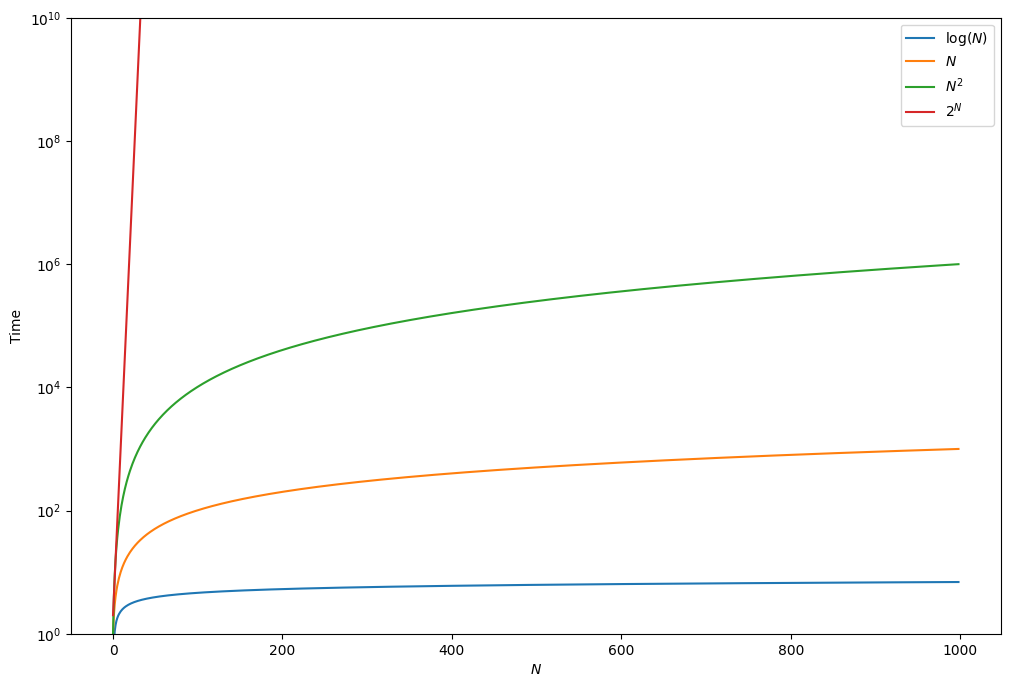

In [2]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

plt.figure(figsize = (12, 8))
N = np.arange(1, 1e3)
plt.plot(np.log(N), label = '$\log(N)$')
plt.plot(N, label = '$N$')
plt.plot(N**2, label = '$N^2$')
plt.plot(2**N, label = '$2^N$')
plt.yscale('log')
plt.xlabel('$N$')
plt.ylabel('Time')
plt.ylim(1e0, 1e10)
plt.legend()
plt.show()

# The Profiler

## Using the magic command
Even if it does not change the Big-O complexity of a program, many programmers will spend long hours to make their code run twice as fast or to gain even smaller improvements.

There are ways to check the run time of the code in the Jupyter notebook, here we will introduce the magic commands to do that:

* %time: Get the run time of a single statement
* %timeit: Get the repeated run time of a single statement
* %%time: Get the run time of all the code in the cell
* %%timeit: Get the repeated run time of a cell

Notice that the double percent magic command will measure the run time for all the code in a cell, while the single percent command only works for a single statement. 

In [3]:
%time sum(range(200))

CPU times: total: 0 ns
Wall time: 53.9 μs


19900

In [4]:
%timeit sum(range(200))

2.9 μs ± 68.2 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [5]:
%%time
s = 0
for i in range(200):
    s += i

CPU times: total: 0 ns
Wall time: 99.9 μs


In [6]:
%%timeit
s = 0
for i in range(200):
    s += i

14.4 μs ± 818 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


## Use Python Profiler

You could also use the Python profiler (you can read more in the Python documentation) to profile the code you write. In Jupyter notebook the magic commands are:

* %prun: Run a single statement through the python code profiler
* %%prun: Run a cell through the python code profiler

Let's see the following example, that sums random numbers over and over again.

In [7]:
import numpy as np

def slow_sum(n, m):

    for i in range(n):
        # we create a size m array of random numbers
        a = np.random.rand(m)

        s = 0
        # in this loop we iterate through the array
        # and add elements to the sum one by one
        for j in range(m):
            s += a[j]   

%prun slow_sum(1000, 10000)

         2712 function calls (2576 primitive calls) in 5.551 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    4.815    4.815    4.815    4.815 3280404660.py:3(slow_sum)
        9    0.559    0.062    0.559    0.062 {built-in method _imp.create_dynamic}
        4    0.059    0.015    0.113    0.028 <frozen importlib._bootstrap_external>:1211(get_data)
        4    0.053    0.013    0.053    0.013 {built-in method _io.open_code}
       34    0.018    0.001    0.018    0.001 {built-in method nt.stat}
        1    0.009    0.009    0.009    0.009 {built-in method nt.replace}
      9/5    0.007    0.001    0.262    0.052 {built-in method _imp.exec_dynamic}
        4    0.007    0.002    0.007    0.002 {method '__exit__' of '_io._IOBase' objects}
      1/0    0.005    0.005    0.000          {built-in method select.select}
       14    0.003    0.000    0.016    0.001 <frozen importlib._bootstrap_external>:164(_path_i

The table is showing the following columns (from Python Profiler)

>**ncalls**: for the number of calls,  
**tottime**: for the total time spent in the given function (and excluding time made in calls to sub-functions),  
**percall**: is the quotient of tottime divided by ncalls  
**cumtime** is the total time spent in this and all subfunctions (from invocation till exit). This figure is accurate even for recursive functions.  
**percall** is the quotient of cumtime divided by primitive calls

# Rest of Exercises (9 pt)

For the first few exercises,

### Exercise 2 (1 pt)

Pick a format for your Overleaf/Latex Document (default article is fine)

### Exercise 3 (1 pt)

Create an itemized list for this project brainstorming exercise, using 
```
\begin{itemize}
    \item First item
    \item Second item
    \item Third item
\end{itemize}
```

### Exercise 3 (1 pt)

In the Overleaf document for item 1, list $\sim$ 1-3 project that you are interested in learning more about

### Exercise 4 (1 pt)

Are you taking this course for honors credit? Have you submitted the honors course request? 

### Exercise 5 (1 pt)

What ~1-3 other people in the course might you be interested in "collaborating" with? Do you know if they are also taking this course for honors credit?

### Exercise 6 (1 pt)

What project are your collaborators interested in working on? Are you interested in also learning about their project? Do you have any suggestions and/or comments?

### Exercise 7 (1 pt)

Share the link to your overleaf document, using the "share", "turn on link sharing", and "others can view". Paste the link in the markdown cell below

**Answer here**
https://www.overleaf.com/read/vttfgtddnxcp#e09e87

### Exercise 8 (1 pt)

How would you define the size of the following tasks?

- Solving a jigsaw puzzle.

- Passing a handout to a class.

- Walking to class.

- Finding a name in dictionary.

**Answer here**
1) the size of jigsaw is the total number of pieces
2) size of passing out handout is dependant on amount of handouts
3) Size of walk depends on length of paths taken and amount of paths taken
4) Size of finding a name is # of names of simular initial, then finding name amongs simualr initials

### Exercise 9 (1 pt)

For the tasks given in the previous problem, what would you say is the Big-O complexity of the tasks in terms of the size definitions you gave?

**Answer here**
1) O(n)
2) O(n)
3) O(n)
4) O(n^2)

### Exercise 10 (1 pt)
Run the following two iterative implementations of finding Fibonacci numbers in the line_profiler as well as using the magic command to get the repeated run time. The first implementation preallocates memory to an array that stores all the Fibonacci numbers. The second implementation expands the list at each iteration of the for-loop.

In [32]:

import numpy as np

def my_fib_iter1(n):
    out = np.zeros(n)
    
    out[:2] = 1
    
    for i in range(2, n):
        out[i] = out[i-1] + out[i-2]
        
    return out

def my_fib_iter2(n):
    
    out = [1, 1]
    
    for i in range(2, n):
        out.append(out[i-1]+out[i-2])
        
    return np.array(out)


In [34]:
%%time
def my_fib_iter1(n):
    out = np.zeros(n)
    
    out[:2] = 1
    
    for i in range(2, n):
        out[i] = out[i-1] + out[i-2]
        
    return out

CPU times: total: 0 ns
Wall time: 27.7 μs


In [35]:
%%time
def my_fib_iter2(n):
    
    out = [1, 1]
    
    for i in range(2, n):
        out.append(out[i-1]+out[i-2])
        
    return np.array(out)

CPU times: total: 0 ns
Wall time: 26.2 μs
